EfficientNetModel(
  (efficientnet): EfficientNet(
    (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          

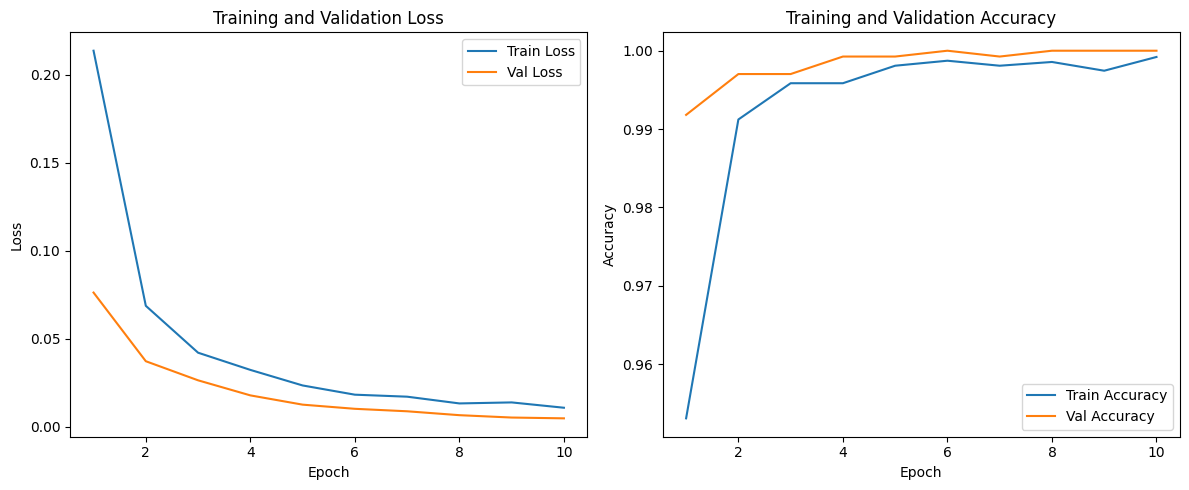

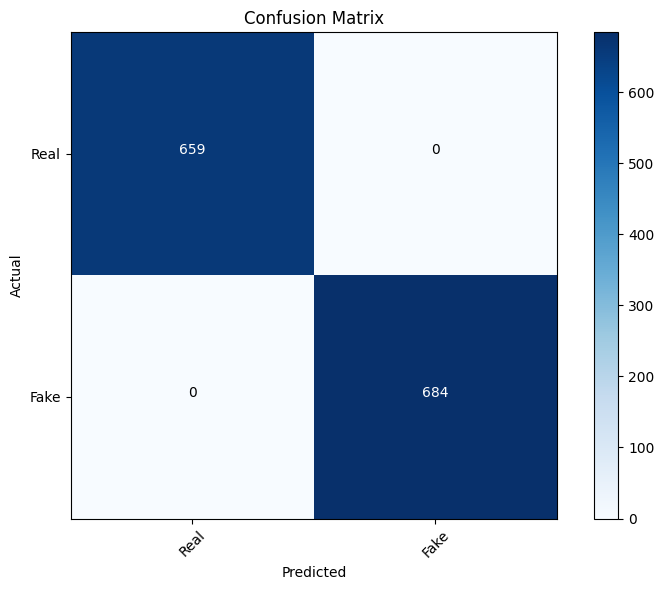

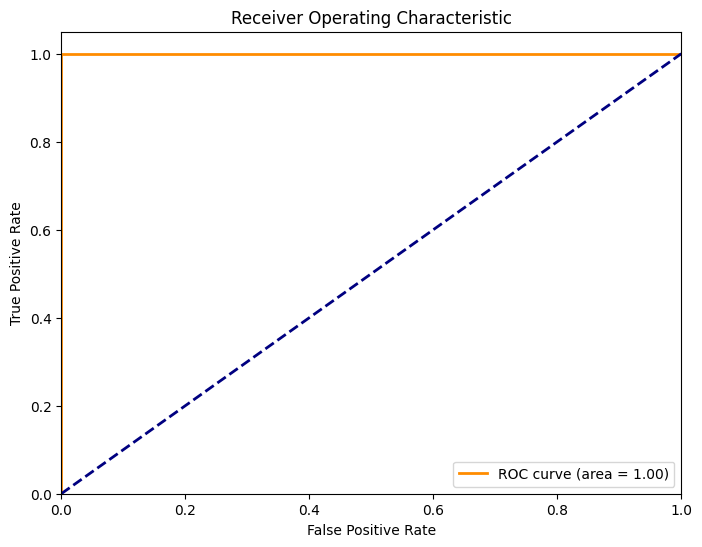

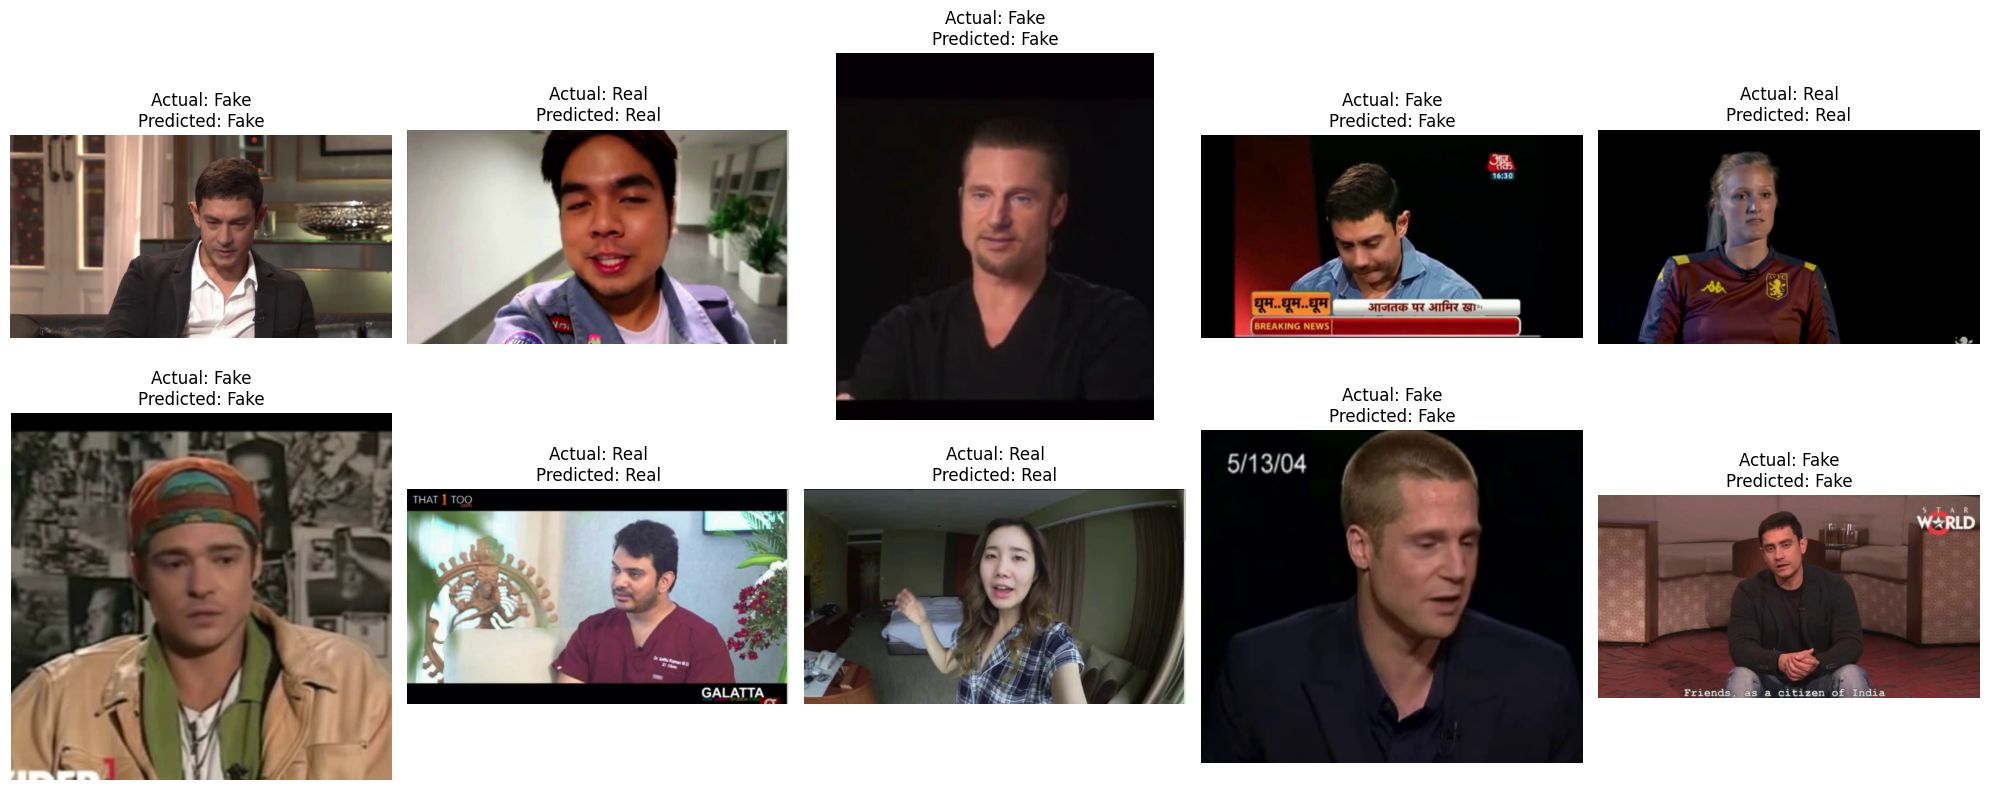

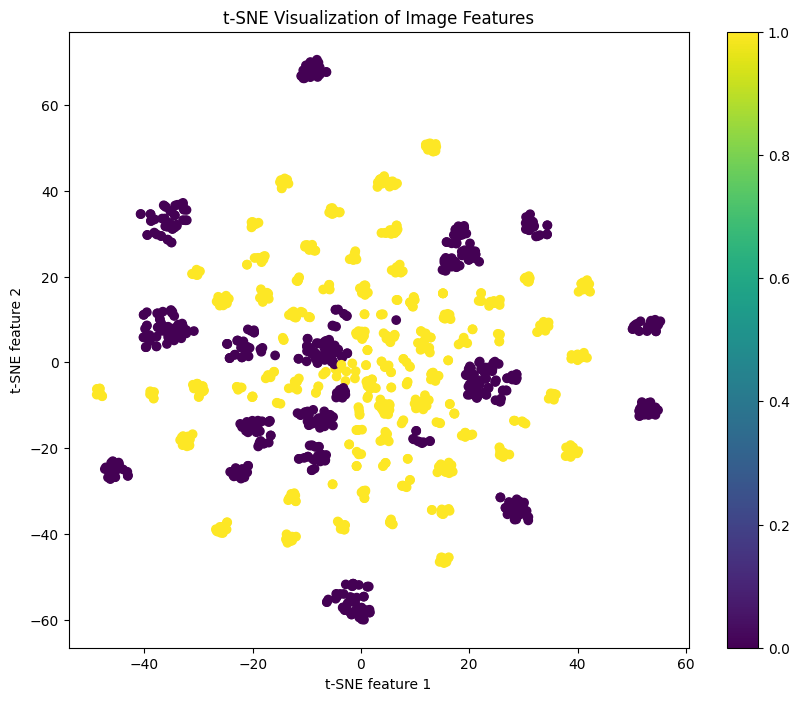

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import timm  # PyTorch Image Models
from torchinfo import summary  # For model summary

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom Dataset
class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return None, None

        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the dataset
data_dir = 'C://Users//Sinchan A//Desktop//Internship//vid'
real_dir = os.path.join(data_dir, 'real')
fake_dir = os.path.join(data_dir, 'fake')
real_image_paths = [os.path.join(real_dir, img) for img in os.listdir(real_dir)]
fake_image_paths = [os.path.join(fake_dir, img) for img in os.listdir(fake_dir)]

image_paths = real_image_paths + fake_image_paths
labels = [1] * len(real_image_paths) + [0] * len(fake_image_paths)

# Split the data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(image_paths, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Create datasets and dataloaders
train_dataset = ImageDataset(X_train, y_train, transform=transform)
val_dataset = ImageDataset(X_val, y_val, transform=transform)
test_dataset = ImageDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define the model using EfficientNet
class EfficientNetModel(nn.Module):
    def __init__(self, n_classes):
        super(EfficientNetModel, self).__init__()
        self.efficientnet = timm.create_model('efficientnet_b3', pretrained=True)
        self.n_features = self.efficientnet.classifier.in_features
        self.efficientnet.classifier = nn.Linear(self.n_features, n_classes)

    def forward(self, x):
        return self.efficientnet(x)

    def extract_features(self, x):
        return self.efficientnet.forward_features(x)

# Assuming binary classification (0: fake, 1: real)
model = EfficientNetModel(2).to(device)
print(model)

# Summary of the model
summary(model, input_size=(1, 3, 224, 224))

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.efficientnet.classifier.parameters(), lr=0.001)

# Training function
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Evaluation function
def evaluate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(torch.softmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

# Training loop
num_epochs = 10
train_losses, train_accs = [], []
val_losses, val_accs = [], []
val_precisions, val_recalls, val_f1s = [], [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    
    val_precision = precision_score(val_labels, np.argmax(val_preds, axis=1), average='binary')
    val_recall = recall_score(val_labels, np.argmax(val_preds, axis=1), average='binary')
    val_f1 = f1_score(val_labels, np.argmax(val_preds, axis=1), average='binary')

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")
    print()

# Final evaluation on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
test_precision = precision_score(test_labels, np.argmax(test_preds, axis=1), average='binary')
test_recall = recall_score(test_labels, np.argmax(test_preds, axis=1), average='binary')
test_f1 = f1_score(test_labels, np.argmax(test_preds, axis=1), average='binary')

print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1: {test_f1:.4f}")

# Visualizations
# 1. Training and Validation Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.tight_layout()
plt.show()

# 2. Confusion Matrix
cm = confusion_matrix(test_labels, np.argmax(test_preds, axis=1))

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Real', 'Fake'], rotation=45)
plt.yticks(tick_marks, ['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(test_labels, np.array(test_preds)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 4. Display some test images with actual and predicted output
test_image_paths = X_test[:10]  # Take first 10 test images
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))

model.eval()
with torch.no_grad():
    for i, img_path in enumerate(test_image_paths):
        ax = axes[i // 5, i % 5]
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        
        img_tensor = transform(img).unsqueeze(0).to(device)
        output = model(img_tensor)
        prediction = torch.softmax(output, dim=1).cpu().numpy()[0]
        
        actual = 'Real' if y_test[i] == 1 else 'Fake'
        predicted = 'Real' if prediction[1] > 0.5 else 'Fake'
        
        ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")
        ax.axis('off')

plt.tight_layout()
plt.show()

# 5. t-SNE Visualization
def extract_features(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for inputs, batch_labels in dataloader:
            inputs = inputs.to(device)
            # Get the output of the second-to-last layer
            feature = model.extract_features(inputs)
            feature = torch.flatten(feature, 1)
            features.append(feature.cpu().numpy())
            labels.extend(batch_labels.numpy())
    
    return np.concatenate(features), np.array(labels)

# Extract features
features, labels = extract_features(model, test_loader, device)

# Normalize the features
scaler = StandardScaler()
normalized_features = scaler.fit_transform(features)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(normalized_features)

# Create the t-SNE plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='viridis')
plt.colorbar(scatter)
plt.title('t-SNE Visualization of Image Features')
plt.xlabel('t-SNE feature 1')
plt.ylabel('t-SNE feature 2')
plt.show()
